<a href="https://colab.research.google.com/github/jayhdajoiner/Jayhda_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment1_JayhdaJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** Jayhda Joiner    **Date:** Sept 6th

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [3]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [ ]:
# how many rows, which columns, what types?
students.info()

# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

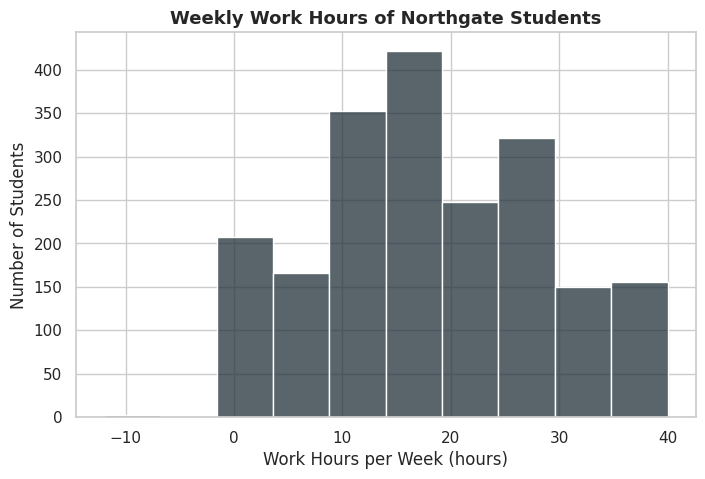

In [4]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()

sns.histplot(
    data=students,
    x="work_hours_per_week",
    bins=10,
    color=NAVY,
    ax=ax
)

ax.set_title("Weekly Work Hours of Northgate Students")
ax.set_xlabel("Work Hours per Week (hours)")
ax.set_ylabel("Number of Students")

plt.show()

**STAR story — Q1** *(write in your own words)*


**My Answer-** The chart shows 2027, which is the weekly work hours. The students wored around 17-18 hours per week and the middle half worked between 10-25 hours. Overall, the hours were spread out amongst the students with some working 40 hours. One weird/unusual value was the -12 though.

In [5]:
students["work_hours_per_week"].describe()

,work_hours_per_week
count,2027.000000
mean,17.284164
std,10.401333
min,-12.000000
25%,10.000000
50%,18.000000
75%,25.000000
max,40.000000


### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

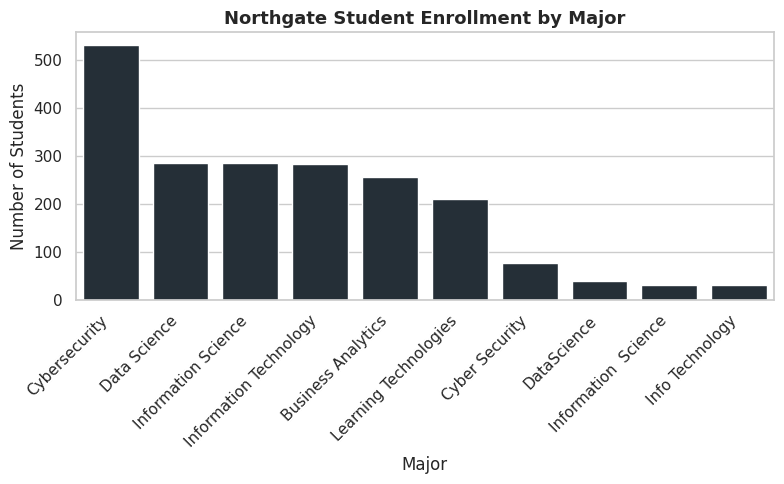

In [6]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

major_counts = (
    students["major"]
    .value_counts()
    .reset_index()
)

major_counts.columns = ["major", "count"]

fig, ax = plt.subplots()

sns.barplot(
    data=major_counts,
    x="major",
    y="count",
    color=NAVY,
    ax=ax
)

ax.set_title("Northgate Student Enrollment by Major")
ax.set_xlabel("Major")
ax.set_ylabel("Number of Students")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


In [7]:
students["major"].value_counts()

,count
major,
Cybersecurity,530
Data Science,285
Information Science,285
Information Technology,283
Business Analytics,255
Learning Technologies,210
Cyber Security,76
DataScience,39
Information Science,32


**STAR story — Q2** *(write in your own words)*

**My Anwser —** The chart compares the differnt enrollments across the majors at Northgate. Cybersecurity has the highest with 530 students, then data science and information science and IT with 285 students each. However the data on the graph is a bit inconsistent because there is Cybersecurity and also Cyber Security with vastly different values on the graph. It's the same with the Data Science and IT values. These would have to be checked and fixed before the final enrollement comparison.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

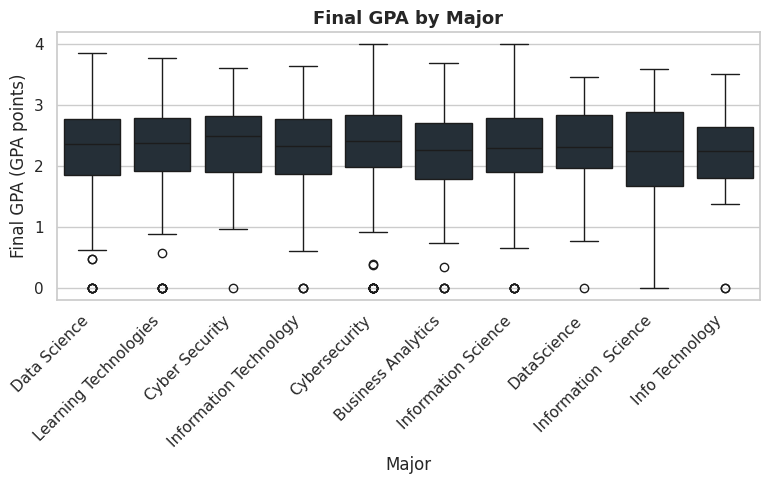

In [8]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()

sns.boxplot(
    data=students,
    x="major",
    y="final_gpa",
    color=NAVY,
    ax=ax
)

ax.set_title("Final GPA by Major")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA (GPA points)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [9]:
students.groupby("major")["final_gpa"].describe()

,count,mean,std,min,25%,50%,75%,max
major,,,,,,,,
Business Analytics,255.0,2.244863,0.678391,0.0,1.7950,2.270,2.7050,3.69
Cyber Security,76.0,2.376711,0.693796,0.0,1.9075,2.500,2.8300,3.62
Cybersecurity,530.0,2.352151,0.696768,0.0,1.9900,2.410,2.8475,4.00
Data Science,285.0,2.296211,0.729748,0.0,1.8600,2.360,2.7800,3.86
DataScience,39.0,2.322821,0.735981,0.0,1.9750,2.310,2.8350,3.47
Info Technology,32.0,2.168750,0.786949,0.0,1.8000,2.255,2.6475,3.52
Information Science,32.0,2.270000,0.816855,0.0,1.6675,2.255,2.8850,3.59
Information Science,285.0,2.298667,0.717917,0.0,1.9000,2.300,2.7900,4.00
Information Technology,283.0,2.296714,0.657298,0.0,1.8750,2.330,2.7800,3.64


**STAR story — Q3** *(write in your own words)*

**My Answer —** This chart compares GPAs for specific majors. Overall, the GPAs are similar, and are all around the 2.3-2.5 range. Cyber Secirity has the highest median GPA whule IT and IS have the lowest medians which are around 2.6. The inconsistent majors from the other chart could offset the comparisons as well.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

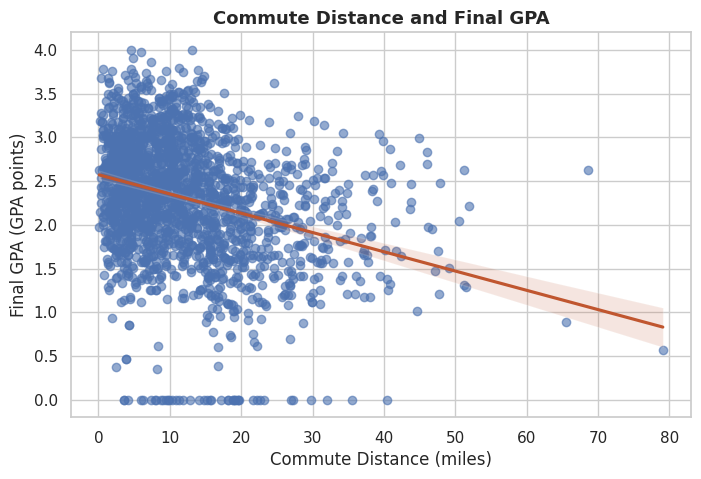

In [10]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()

sns.regplot(
    data=students,
    x="commute_miles",
    y="final_gpa",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": RUST},
    ax=ax
)

ax.set_title("Commute Distance and Final GPA")
ax.set_xlabel("Commute Distance (miles)")
ax.set_ylabel("Final GPA (GPA points)")

plt.show()

**STAR story — Q4** *(write in your own words)*

**My Answer —** The chart shows the relationship between the distance they commuted with the final GPAs. The correlation is about -.3, which shows a weak relationship between the two. Students with longer commutes have slightly lower GPAs than the rest. Because this is only an association, commute distance doesn't have a direct correlation to a lower GPA.

In [12]:
students[["commute_miles", "final_gpa"]].corr()

,commute_miles,final_gpa
commute_miles,1.000000,-0.295108
final_gpa,-0.295108,1.000000


### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

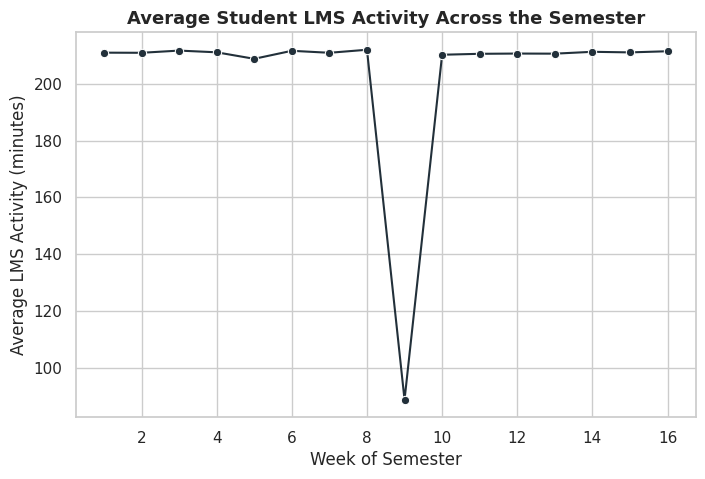

In [13]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

weekly_avg = (
    weekly.groupby("week")["minutes_active"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots()

sns.lineplot(
    data=weekly_avg,
    x="week",
    y="minutes_active",
    marker="o",
    color=NAVY,
    ax=ax
)

ax.set_title("Average Student LMS Activity Across the Semester")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average LMS Activity (minutes)")

plt.show()

In [14]:
weekly_avg

,week,minutes_active
0,1,210.9805
1,2,210.9365
2,3,211.7105
3,4,211.1095
4,5,208.8125
5,6,211.6380
6,7,210.9370
7,8,212.0085
8,9,88.6370
9,10,210.2460


**STAR story — Q5** *(write in your own words)*

**My answer —** The chart shows the average number of students that were active in the LMS each week. The overall student engagement stayed very consistent at about 209-212 minutes per week. Week 9 dropped down to 88.6 minutes before going back to week 10 though. This break makes me wonder if homecoming or another big event contributed to this decline.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**My question:** Do students who dropped out have different final GPAs than students who stayed enrolled?



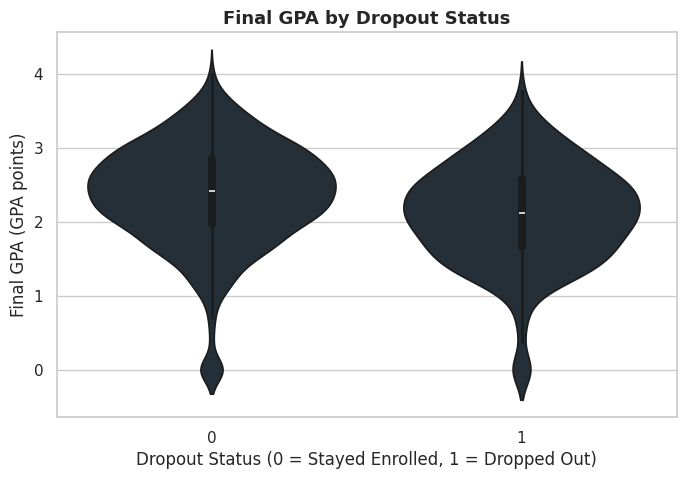

In [15]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---

fig, ax = plt.subplots()

sns.violinplot(
    data=students,
    x="dropped_out",
    y="final_gpa",
    color=NAVY,
    ax=ax
)

ax.set_title("Final GPA by Dropout Status")
ax.set_xlabel("Dropout Status (0 = Stayed Enrolled, 1 = Dropped Out)")
ax.set_ylabel("Final GPA (GPA points)")

plt.show()


In [16]:
students.groupby("dropped_out")["final_gpa"].describe()

,count,mean,std,min,25%,50%,75%,max
dropped_out,,,,,,,,
0,1600.0,2.361213,0.702921,0.0,1.970,2.415,2.84,4.00
1,427.0,2.106112,0.678730,0.0,1.655,2.120,2.57,3.76


**STAR story — Part B** *(write in your own words)*

 **My Answer —** The chart compares the GPA with people who stayed enrolled in school and who dropped out. Students who stayed enrolled have had a higher GPA average which were about 2.36 with a median of 2.42. Students who dropped out had a lower average of about 2.11 with a median of 2.12. These distrubutions overlap, so GPA alone doesn't completely separate the two. To make this more accurate, I would need to look at other factor like attendance, LMS activity, oe work hours.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.